In [73]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy.stats import pearsonr

In [74]:
df = pd.read_csv('Final Integrated data for third question.csv')

df.head()


,Channel_Name,Channel_ID,Channel_URL,Views_Last_Year,Likes_Last_Year,Comments_Last_Year,Videos_Counted,Channel_Type
0,ABC Educational Channel,UC4eJ_rAyzxH9XZEj76ZMzww,https://www.youtube.com/channel/UC4eJ_rAyzxH9X...,2157,41,0,12,Educational
1,Educational Channel,UCXx6kmgnS9h8SH8vZ_ZJThg,https://www.youtube.com/channel/UCXx6kmgnS9h8S...,1392,27,1,12,Educational
2,Meekah - Educational Videos for Kids,UCx3RchaoRFpDpB60x7xRREw,https://www.youtube.com/channel/UCx3RchaoRFpDp...,590233,3599,0,12,Educational
3,Kids Tv - Preschool Learning Videos,UCpnDeduW4x-ww_UOaUAH6WQ,https://www.youtube.com/channel/UCpnDeduW4x-ww...,125970,436,0,12,Educational
4,Toddler Learning Videos For Kids - Lucas & Fri...,UCYqksDldZTkKmsrBb4OGJ9g,https://www.youtube.com/channel/UCYqksDldZTkKm...,86765949,183510,0,12,Educational


In [75]:

df['Total_Engagement'] = df['Likes_Last_Year'] + df['Comments_Last_Year']
df['Engagement_Rate'] = (df['Total_Engagement'] / df['Views_Last_Year'] )
df

,Channel_Name,Channel_ID,Channel_URL,Views_Last_Year,Likes_Last_Year,Comments_Last_Year,Videos_Counted,Channel_Type,Total_Engagement,Engagement_Rate
0,ABC Educational Channel,UC4eJ_rAyzxH9XZEj76ZMzww,https://www.youtube.com/channel/UC4eJ_rAyzxH9X...,2157,41,0,12,Educational,41,0.019008
1,Educational Channel,UCXx6kmgnS9h8SH8vZ_ZJThg,https://www.youtube.com/channel/UCXx6kmgnS9h8S...,1392,27,1,12,Educational,28,0.020115
2,Meekah - Educational Videos for Kids,UCx3RchaoRFpDpB60x7xRREw,https://www.youtube.com/channel/UCx3RchaoRFpDp...,590233,3599,0,12,Educational,3599,0.006098
3,Kids Tv - Preschool Learning Videos,UCpnDeduW4x-ww_UOaUAH6WQ,https://www.youtube.com/channel/UCpnDeduW4x-ww...,125970,436,0,12,Educational,436,0.003461
4,Toddler Learning Videos For Kids - Lucas & Fri...,UCYqksDldZTkKmsrBb4OGJ9g,https://www.youtube.com/channel/UCYqksDldZTkKm...,86765949,183510,0,12,Educational,183510,0.002115
...,...,...,...,...,...,...,...,...,...,...
1011,Only Live Music Videos,UCzuskiw671HtmFT0PHDNf2w,https://www.youtube.com/channel/UCzuskiw671Htm...,79,3,0,12,Entertainment,3,0.037975
1012,Sonic Music Videos,UCHi-GiBFzOrBqToZvtY1FMQ,https://www.youtube.com/channel/UCHi-GiBFzOrBq...,743287,8051,227,12,Entertainment,8278,0.011137
1013,GoAnimate Music Videos,UCSjziqEoS42F_3iHz1H8QmA,https://www.youtube.com/channel/UCSjziqEoS42F_...,307,7,0,12,Entertainment,7,0.022801
1014,AI metal music videos - Clostomy Destruction,UCIQdCAw_BTDxjCeUuP2Zx6Q,https://www.youtube.com/channel/UCIQdCAw_BTDxj...,238813,10921,566,12,Entertainment,11487,0.048100


In [76]:
entertainment = df[df['Channel_Type'] == 'Entertainment']
educational = df[df['Channel_Type'] == 'Educational']

(0.0, 0.2)

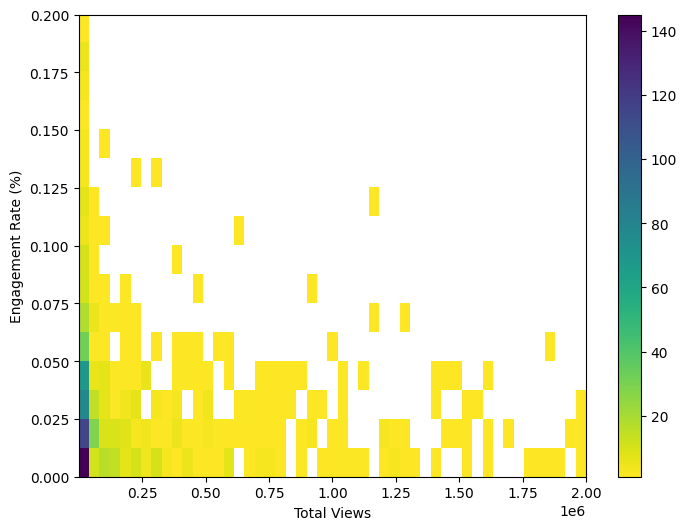

In [117]:
plt.figure(figsize = [18, 6])

plt.subplot(1, 2, 2)

# Use actual data range for bins
bins_x = np.linspace(df['Views_Last_Year'].min(), 2000000, 50)
bins_y = np.linspace(df['Engagement_Rate'].min(), df['Engagement_Rate'].max(), 50)

plt.hist2d(data = df, x = 'Views_Last_Year', y = 'Engagement_Rate', 
           cmin=0.5, cmap='viridis_r', bins = [bins_x, bins_y])
plt.colorbar()
plt.xlabel('Total Views')
plt.ylabel('Engagement Rate (%)')

plt.ylim(0, 0.2) 



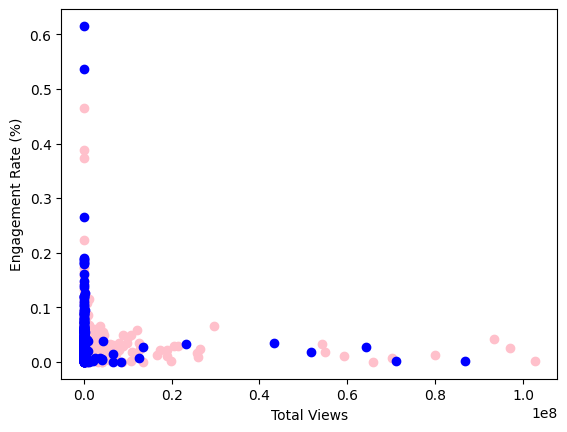

In [ ]:
plt.scatter(data = entertainment, x = 'Views_Last_Year', y = 'Engagement_Rate', color='pink', label='Entertainment');
plt.scatter(data = educational, x = 'Views_Last_Year', y = 'Engagement_Rate', color='blue', label='Educational');
plt.xlabel('Total Views');
plt.ylabel('Engagement Rate (%)');

plt

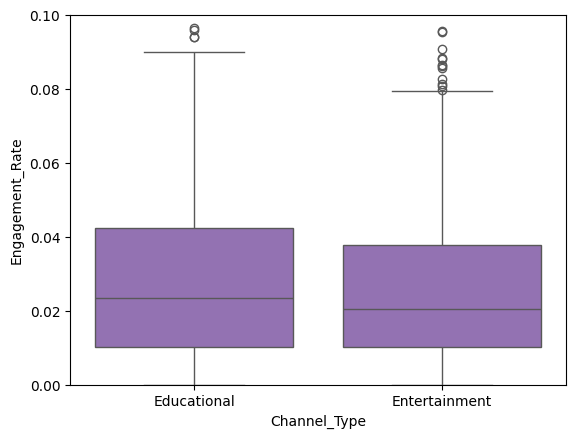

In [82]:
base_color1 = sns.color_palette()[4]

sns.boxplot(data=df, x='Channel_Type', y='Engagement_Rate', color=base_color1)

plt.ylim(0, 0.1) 

plt.show()


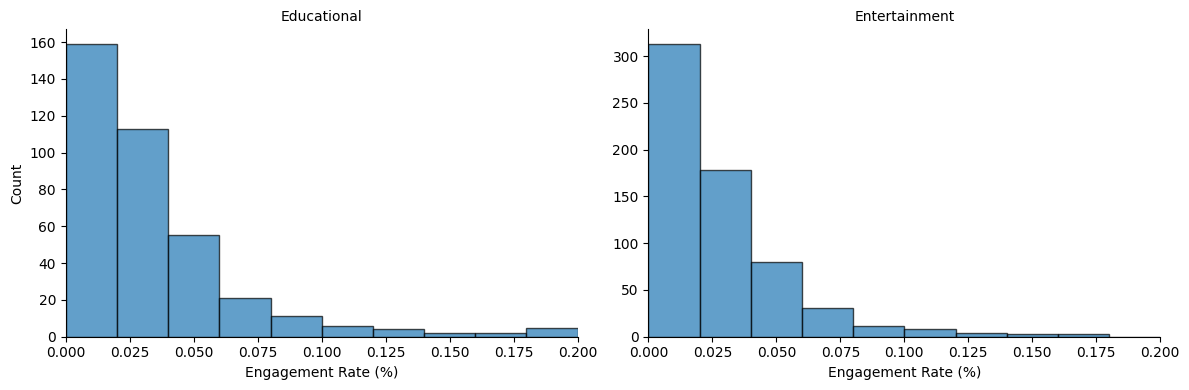

In [87]:
# Adjust bin size for better visualization
bin_edges = np.arange(0, df['Engagement_Rate'].max(), 0.02)  # 0.05 increments

g = sns.FacetGrid(data=df, col='Channel_Category', col_wrap=2, sharey=False, height=4, aspect=1.5)
g.map(plt.hist, 'Engagement_Rate', bins=bin_edges, edgecolor='black', alpha=0.7)
g.set_titles("{col_name}")
g.set_axis_labels("Engagement Rate (%)", "Count")

plt.xlim(0, 0.2) 

g.tight_layout()


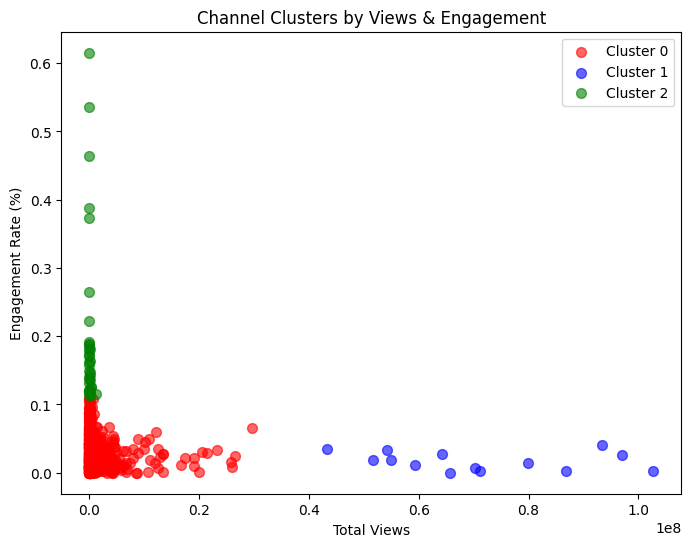

Cluster  Channel_Type 
0        Entertainment    608
         Educational      357
1        Entertainment      9
         Educational        5
2        Educational       19
         Entertainment     18
Name: count, dtype: int64


In [ ]:
from sklearn.cluster import KMeans

# Prepare data for clustering
X = df[['Views_Last_Year', 'Engagement_Rate']].values

# Scale the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Plot clusters
plt.figure(figsize=(8, 6))
colors = ['red', 'blue', 'green', 'orange', 'purple']

for cluster_num in df['Cluster'].unique():
    cluster_data = df[df['Cluster'] == cluster_num]
    plt.scatter(cluster_data['Views_Last_Year'], 
                cluster_data['Engagement_Rate'],
                color=colors[cluster_num],
                alpha=0.6,
                s=50,
                label=f'Cluster {cluster_num}')

plt.xlabel('Total Views')
plt.ylabel('Engagement Rate (%)')
plt.title('Channel Clusters by Views & Engagement')
plt.legend()
plt.show()

# See how clusters relate to channel types
print(df.groupby('Cluster')['Channel_Type'].value_counts())



In [93]:
# SIMPLE CONCLUSION WITH CLUSTERS
print("CONCLUSION FROM CLUSTERS:")

# Check which channel types dominate high-engagement clusters
high_engagement_cluster = df.groupby('Cluster')['Engagement_Rate'].mean().idxmax()

# See what channel types are in the highest engagement cluster
cluster_types = df[df['Cluster'] == high_engagement_cluster]['Channel_Type'].value_counts()

if 'Entertainment' in cluster_types.index:
    print("Entertainment channels dominate the highest engagement cluster")
else:
    print("Educational channels dominate the highest engagement cluster")

CONCLUSION FROM CLUSTERS:
Entertainment channels dominate the highest engagement cluster
